In [1]:
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 21.3 MB/s eta 0:00:00


In [2]:
from ultralytics import YOLO

# check if everything works
model = YOLO("/content/drive/MyDrive/yolo_assignment/runs/detect/train/weights/best.pt")
print("Model loaded successfully!")

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Model loaded successfully!


In [3]:
sizes = [320, 640]

results = {}

for size in sizes:
    metrics = model.val(
        data="/content/drive/MyDrive/yolo_assignment/coco.yaml",
        imgsz=size
    )
    results[size] = metrics

Streaming output truncated to the last 5000 lines.
train: /content/drive/MyDrive/yolo_assignment/coco_yolo/images/val/000000504389.jpg: ignoring corrupt image/label: Label class 38 exceeds dataset class count 10. Possible class labels are 0-9
train: /content/drive/MyDrive/yolo_assignment/coco_yolo/images/val/000000504415.jpg: ignoring corrupt image/label: Label class 38 exceeds dataset class count 10. Possible class labels are 0-9
train: /content/drive/MyDrive/yolo_assignment/coco_yolo/images/val/000000504439.jpg: ignoring corrupt image/label: Label class 22 exceeds dataset class count 10. Possible class labels are 0-9
train: /content/drive/MyDrive/yolo_assignment/coco_yolo/images/val/000000504580.jpg: ignoring corrupt image/label: Label class 23 exceeds dataset class count 10. Possible class labels are 0-9
train: /content/drive/MyDrive/yolo_assignment/coco_yolo/images/val/000000504589.jpg: ignoring corrupt image/label: Label class 29 exceeds dataset class count 10. Possible class labe

In [4]:
for size, m in results.items():
    print(f"\nResolution: {size}")
    print(f"mAP@0.5: {m.box.map50}")
    print(f"mAP@0.5:0.95: {m.box.map}")
    print(f"Precision: {m.box.mp}")
    print(f"Recall: {m.box.mr}")


Resolution: 320
mAP@0.5: 0.6039372252057994
mAP@0.5:0.95: 0.41917794766119093
Precision: 0.71334399512203
Recall: 0.5488946978363506

Resolution: 640
mAP@0.5: 0.7849973574357654
mAP@0.5:0.95: 0.5935332584548307
Precision: 0.8297206659637197
Recall: 0.6937514495615065


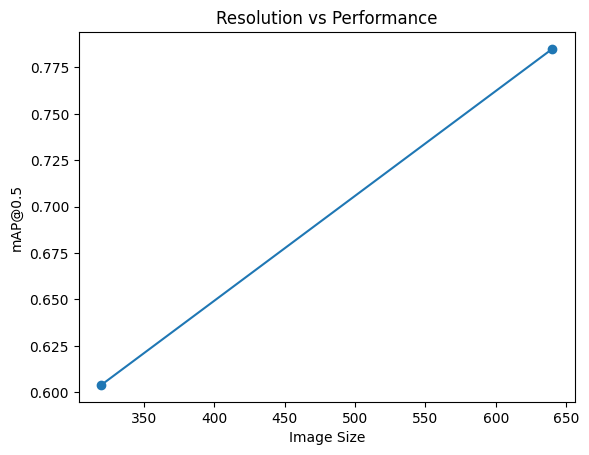

In [5]:
import matplotlib.pyplot as plt

sizes = list(results.keys())
map50 = [results[s].box.map50 for s in sizes]

plt.plot(sizes, map50, marker='o')
plt.xlabel("Image Size")
plt.ylabel("mAP@0.5")
plt.title("Resolution vs Performance")
plt.show()

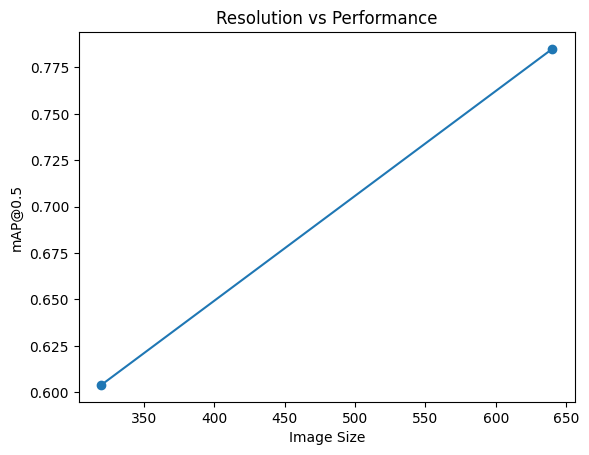

In [6]:
import matplotlib.pyplot as plt

sizes = list(results.keys())
map50 = [results[s].box.map50 for s in sizes]

plt.plot(sizes, map50, marker='o')
plt.xlabel("Image Size")
plt.ylabel("mAP@0.5")
plt.title("Resolution vs Performance")

# ✅ Save image
plt.savefig("/content/drive/MyDrive/yolo_assignment/resolution_plot.png")

plt.show()